# SBSI tutorial: predicting shear response

This notebook walks through the prediction half of SBSI. You load a trained measurement flow and a blending emulator, hand them a catalogue of galaxies, and get back the shear response of that catalogue — the number you calibrate with.

## 1. Setup

Use a kernel in which this SBSI checkout and BlendEMU are installed editable (see the repository README). The notebook never changes `sys.path` and does not depend on the Jupyter server's working directory. The first cell prints both imported package locations so a wrong kernel is immediately visible.

## 2. Point SBSI at a catalogue

`load_catalogue` reads a Feather, Parquet, CSV, or pickle path.

The catalogue bundled with this notebook is a truth-level input catalogue. It holds about 111,000 galaxies with sky positions (`RA`, `DEC`), a magnitude (`r`), a size (`Re`), a shape (`sersic_n`, `axis_ratio`, `position_angle`), a `redshift`, and the applied shear (`g1`, `g2`).

If you need fresh simulated or measured catalogues, `job_blendemu.sh` in this folder shows how to call BlendEMU's pipeline. SBSI does not render or measure images itself.

In [1]:
from pathlib import Path

import sbsi
import blendemu

from sbsi import (
    EmulatorPairingConfig,
    ModelPaths,
    ResponsePredictor,
    example_path,
    get_model,
    load_catalogue,
    load_emulator,
    prepare_forward_catalogue,
    predict_blend_response,
)

print("SBSI:    ", sbsi.__file__)
print("BlendEMU:", blendemu.__file__)

SBSI:     /home/z/Zekang.Zhang/SBSI-master/sbsi/__init__.py
BlendEMU: /home/z/Zekang.Zhang/blendemu/blendemu/__init__.py


In [2]:
INPUT_CATALOGUE = example_path("data", "example_catalog.feather")
input_catalogue = load_catalogue(INPUT_CATALOGUE)

input_catalogue.head()

,index,cata_idx,RA,DEC,g1,g2,position_angle,redshift,Re,axis_ratio,sersic_n,r
0,0,773630,180.185728,0.222420,0.0,0.0,164.396647,1.102414,0.162907,0.697792,0.845730,25.733576
1,1,277869,180.118990,0.236218,0.0,0.0,168.168753,0.642087,0.146840,0.341948,0.513552,24.451671
2,2,28030,180.493363,-0.059868,0.0,0.0,91.671930,0.265863,0.396980,0.409923,1.581997,26.839913
3,3,1066306,180.298198,-0.032319,0.0,0.0,152.511604,1.570225,0.155919,0.489980,1.164548,26.660423
4,4,1241052,180.201385,-0.111354,0.0,0.0,41.145542,1.886374,0.192961,0.262081,0.580749,25.564444


## 3. Load the models

In [3]:
# Frozen release paths:
models = get_model("V3")

# An arbitrary model uses the identical workflow:
custom_models = ModelPaths(
    flow_checkpoints=(
        Path("/path/to/models/flow_s1.pt"),
        Path("/path/to/models/flow_s2.pt"),
    ),
    emulator_model=Path("/path/to/models/emulator.json"),
    emulator_metadata=Path("/path/to/models/emulator_metadata.json"),
)

OBSERVING_CONDITIONS = {
    "pixel_size": 0.2,
    "zero_point": 30.0,
    "psf_fwhm": 0.73,
    "moffat_beta": 2.224,
    "pixel_rms": 0.312,
}

models

ModelPaths(flow_checkpoints=(PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s501_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s502_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s503_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s505_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s506_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s507_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s508_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c

## 4. Predict the response

The response has two parts, and you always need both:

$$R_{\mathrm{model}} = R_{\mathrm{flow}} + R_{\mathrm{blend}}.$$

`R_flow` is *self*-response: how an isolated galaxy's measured shape reacts to shear. `R_blend` is the extra response caused by neighbours sitting in the way.

By default `predict` refuses to run if any of your galaxies fall outside the domain, and tells you how many. That is deliberate: extrapolating a flow is not a small error. If you would rather drop those rows and carry on, pass `strict_domain=False`.

In [4]:
# Load the two models. device=None picks CUDA when available and CPU otherwise;
# use a GPU node for production-scale flow prediction.
emulator = load_emulator(models, conditions=OBSERVING_CONDITIONS, device="cpu")
predictor = ResponsePredictor.load(models, device=None)
print("Condition features:", predictor.condition_features)
print("Measured targets:  ", predictor.target_features)
print("Training domain:   ", predictor.domain)

Condition features: ('e1_input_p', 'e2_input_p', 'sersic_n_input_p', 'r_input_p', 'Re_input_p', 'nbr_flux_near', 'nbr_flux_far', 'nbr_flux_max')
Measured targets:   ('measured_ngmix_g1', 'measured_ngmix_g2', 'measured_mag_auto', 'measured_log_flux_radius')
Training domain:    Domain(magnitude_min=18.0, magnitude_max=25.8, half_light_radius_min=0.5, half_light_radius_max=1.5)


`prepare_forward_catalogue` runs the neighbour search and hands back both views as ordinary DataFrames you can inspect:

- `flow_inputs` — one row per galaxy that survived the cuts, indexed by its row number in your original catalogue.
- `emulator_pairs` — one row per accepted pair, so a crowded galaxy shows up several times.

(Working across several fields or tiles? Pass `group_column` so a galaxy is never paired with a "neighbour" from a different field.)

In [5]:
pairing = EmulatorPairingConfig.from_emulator(emulator)
prepared = prepare_forward_catalogue(input_catalogue, config=pairing)
prepared.emulator_pairs[["primary_row", "secondary_row", "distance"]].head()

# The pair-level predictions are summed into a Series keyed by primary_row.
r_blend = predict_blend_response(emulator, prepared.emulator_pairs)

prediction = predictor.predict(
    prepared.flow_inputs,
    blend_response=r_blend,
    shear=0.02,
    n_samples=64,
)
prediction.summary()

/home/z/Zekang.Zhang/SBSI-master/sbsi/response.py:196: UserWarning: [blendemu:response] 109874 input rows, extrapolation outside training boundaries:
  sersic_n_input_p: 1762/109874 outside [0.513, 5.85] (input range [0.5, 6])
  sersic_n_input_s: 719/109874 outside [0.513, 5.85] (input range [0.5, 6])
  Predictions for these rows are extrapolations and may be unreliable.
  predicted = emulator.predict_on_pairs(pairs, task="response", rescaled=True)


{'model': 'V3',
 'n_objects': 10265,
 'n_seeds': 16,
 'R_flow': 0.869602157594803,
 'R_blend': 0.24973616911571508,
 'R_total': 1.1193383267105181,
 'R_flow_seed_sem': 0.0036968258907953697}

### Distribution of the two response channels

`prediction.flow` and `prediction.blend` are per-object arrays: each galaxy's
self response, and the extra response its neighbours contribute. Their
distributions show how the two channels split object by object, beyond the
catalogue means in `prediction.summary()`.

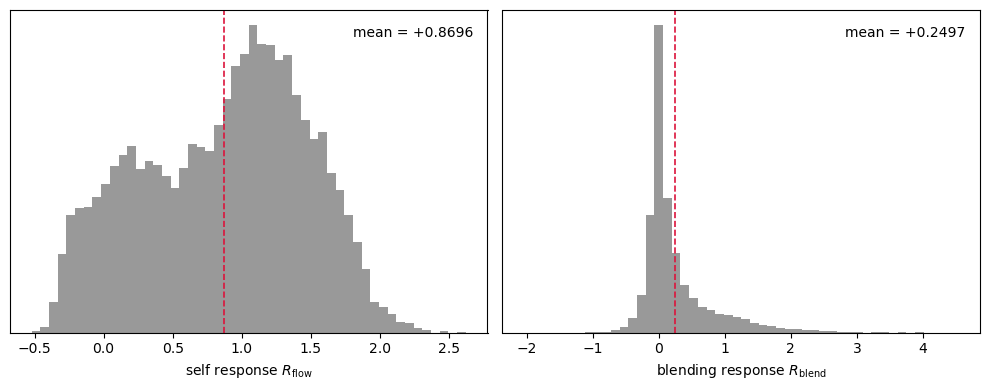

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
channels = (
    (prediction.flow, r"self response $R_{\mathrm{flow}}$"),
    (prediction.blend, r"blending response $R_{\mathrm{blend}}$"),
)
for ax, (values, label) in zip(axes, channels):
    ax.hist(values, bins=50, color="0.6")
    ax.axvline(values.mean(), color="crimson", ls="--", lw=1.2)
    ax.text(0.97, 0.95, f"mean = {values.mean():+.4f}",
            transform=ax.transAxes, ha="right", va="top")
    ax.set_xlabel(label)
    ax.set_yticks([])
fig.tight_layout()
plt.show()

### The flow's direct output: measured-parameter distributions

`predict` reduces the flow to one number per object, but underneath, the flow
models the joint distribution of *four* measured parameters -- shape
($g_1$, $g_2$), magnitude, and size -- conditioned on each galaxy's input
properties. `sample_measurement` draws that distribution directly: pooled
over the 16-seed ensemble at 256 draws per seed, in physical units. Below,
three representative in-domain galaxies (bright, median, and faint) are
compared through their measured-shape distribution (left) and measured
magnitude--size distribution (right). The faint galaxy's contours spread
much wider -- the measurement uncertainty the response calculation averages
over.

In [7]:
from sbsi import sample_measurement

# pick three galaxies: bright, middle, faint
r = prepared.flow_inputs["r_input_p"]

bright = r.idxmin()
middle = (r - r.median()).abs().idxmin()
faint = r.idxmax()

rows = prepared.flow_inputs.loc[[bright, middle, faint]]

draw = sample_measurement(models, rows, n_samples=512)

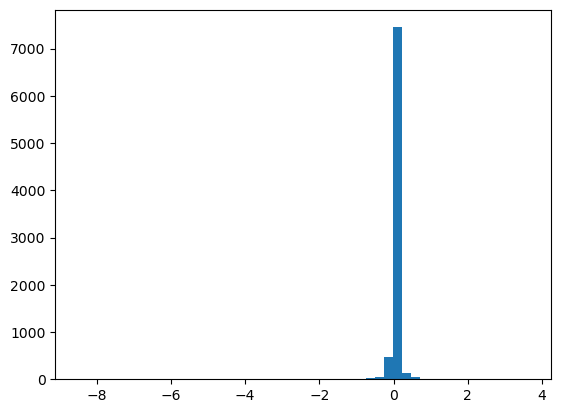

In [8]:
plt.hist(draw.column("measured_ngmix_g2")[0],bins=50);

In [9]:
prepared.flow_inputs

,input_index,index_input_p,cata_idx_input_p,RA_input_p,DEC_input_p,g1_input_p,g2_input_p,position_angle_input_p,redshift_input_p,Re_input_p,...,g2_input_s,position_angle_input_s,redshift_input_s,Re_input_s,axis_ratio_input_s,sersic_n_input_s,r_input_s,nbr_flux_near,nbr_flux_far,nbr_flux_max
primary_row,,,,,,,,,,,,,,,,,,,,,
17,17,17,595488,180.451363,-0.164417,0.0,0.0,118.435788,0.845267,0.532736,...,-0.0,69.459453,1.368476,0.646854,0.753810,0.838014,22.566389,0.000000,2.219584,2.144065
25,25,25,654544,180.040683,0.011035,0.0,0.0,155.234771,0.969587,1.388123,...,0.0,131.752897,0.661343,0.490965,0.403372,0.729814,25.443974,1.032224,2.880742,2.871972
30,30,30,989524,180.292242,0.031067,0.0,0.0,42.482095,1.107298,0.794534,...,0.0,103.310708,1.866923,0.153520,0.667175,0.897573,25.897689,1.564342,2.078171,1.949448
46,46,46,592162,180.196830,0.201772,0.0,0.0,2.438734,1.007511,1.096705,...,0.0,113.418317,1.840748,0.385002,0.445807,1.717991,23.382888,0.000000,1.836629,1.820947
91,91,91,627628,180.079954,0.125820,0.0,0.0,97.738436,0.919742,0.535041,...,0.0,112.134940,2.764148,0.324351,0.827621,0.527925,22.097979,0.000000,2.552512,2.330336
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111141,111141,111141,110227,180.492612,-0.203275,0.0,-0.0,114.184881,0.312702,0.800502,...,-0.0,170.643593,0.554615,0.331393,0.729151,1.337970,26.840562,0.568132,1.582798,1.314084
111155,111155,111155,92835,180.005329,0.053182,0.0,-0.0,13.486398,0.323875,0.629919,...,0.0,55.172255,1.703311,0.237605,0.521278,1.074071,25.890379,0.000000,2.033804,1.746894
111176,111176,111176,579650,180.429699,-0.008376,0.0,0.0,168.994038,0.886696,0.582821,...,0.0,8.561160,0.881481,0.159780,0.764152,0.576243,26.455053,0.000000,2.732121,2.722842


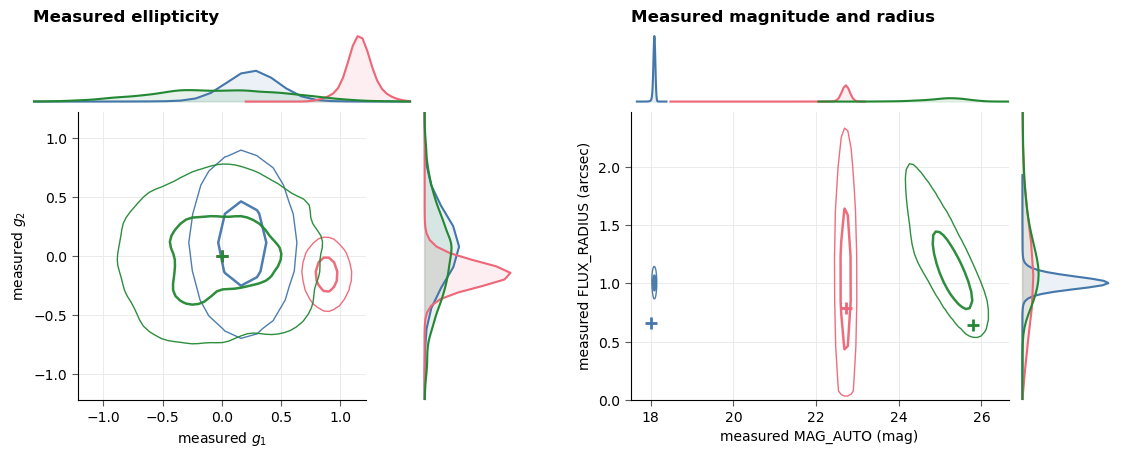

In [10]:
from matplotlib.lines import Line2D
from scipy import ndimage

MASS_LEVELS = (0.393, 0.865)
SMOOTHING = 1.6
PAD_BINS = int(np.ceil(4 * SMOOTHING))
COLORS = ("#4477AA", "#EE6677", "#228833")  # colorblind-safe


def extended_edges(edges, pad_bins=PAD_BINS):
    """Extend uniform histogram edges to match zero-padded counts."""
    bin_width = edges[1] - edges[0]
    padded_edges = edges[0] + bin_width * np.arange(-pad_bins, len(edges) + pad_bins)
    return padded_edges


def density_contours(ax, x, y, color, bins=50, y_floor=None):
    """Draw highest-density contours enclosing MASS_LEVELS of the samples."""
    x = np.asarray(x)
    y = np.asarray(y)
    finite = np.isfinite(x) & np.isfinite(y)
    counts, x_edges, y_edges = np.histogram2d(x[finite], y[finite], bins=bins)
    density = np.pad(counts.T, PAD_BINS, mode="constant")
    x_edges = extended_edges(x_edges)
    y_edges = extended_edges(y_edges)
    density = ndimage.gaussian_filter(density, sigma=SMOOTHING, mode="constant")
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])

    if y_floor is not None:
        keep = y_centers > y_floor
        density = density[keep]
        y_centers = y_centers[keep]
        density = np.vstack([np.zeros(density.shape[1]), density])
        y_centers = np.concatenate([[y_floor], y_centers])

    ranked = np.sort(density.ravel())[::-1]
    cumulative_mass = np.cumsum(ranked) / ranked.sum()
    thresholds = [ranked[np.searchsorted(cumulative_mass, mass)] for mass in MASS_LEVELS]
    levels = np.unique(np.sort(thresholds))

    return ax.contour(
        x_centers,
        y_centers,
        density,
        levels=levels,
        colors=[color] * len(levels),
        linewidths=np.linspace(1.0, 1.8, len(levels)),
        alpha=0.95,
    )


def marginal_density(values, bins=70, lower_bound=None):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    counts, edges = np.histogram(values, bins=bins)
    counts = np.pad(counts, PAD_BINS, mode="constant")
    edges = extended_edges(edges)
    density = ndimage.gaussian_filter1d(
        counts.astype(float), sigma=SMOOTHING, mode="constant"
    )
    centers = 0.5 * (edges[:-1] + edges[1:])
    if lower_bound is not None:
        keep = centers > lower_bound
        centers = np.concatenate([[lower_bound], centers[keep]])
        density = np.concatenate([[0.0], density[keep]])
    density /= np.trapz(density, centers)
    return centers, density


def make_joint_axes(fig, spec, title):
    grid = spec.subgridspec(
        2, 2, height_ratios=(1, 4), width_ratios=(4, 1), hspace=0.04, wspace=0.04
    )
    joint = fig.add_subplot(grid[1, 0])
    top = fig.add_subplot(grid[0, 0], sharex=joint)
    right = fig.add_subplot(grid[1, 1], sharey=joint)
    top.set_title(title, loc="left", weight="bold", pad=8)
    top.set_axis_off()
    right.set_axis_off()
    return joint, top, right


def add_distribution(
    joint, top, right, x, y, x_input, y_input, color, y_floor=None
):
    contours = density_contours(joint, x, y, color, y_floor=y_floor)

    x_grid, x_density = marginal_density(x)
    y_grid, y_density = marginal_density(y, lower_bound=y_floor)
    top.plot(x_grid, x_density, color=color, lw=1.5)
    top.fill_between(x_grid, x_density, color=color, alpha=0.10)
    right.plot(y_density, y_grid, color=color, lw=1.5)
    right.fill_betweenx(y_grid, y_density, color=color, alpha=0.10)

    joint.scatter(
        x_input, y_input, marker="+", s=85, linewidth=2.0, color=color, zorder=5
    )
    return contours


def enclosed_limits(contours, coordinate, markers, padding=0.06, lower_bound=None):
    """Limit an axis to complete contour paths and their input markers."""
    segments = [
        path[:, coordinate]
        for contour in contours
        for level in contour.allsegs
        for path in level
        if len(path)
    ]
    values = np.concatenate([*segments, np.asarray(markers, dtype=float)])
    values = values[np.isfinite(values)]
    low, high = values.min(), values.max()
    margin = padding * max(high - low, np.finfo(float).eps)
    low, high = low - margin, high + margin
    if lower_bound is not None:
        low = max(lower_bound, low)
    return low, high


fig = plt.figure(figsize=(12, 5.4))
outer = fig.add_gridspec(1, 2, wspace=0.24)
shape_axes = make_joint_axes(fig, outer[0], "Measured ellipticity")
photometry_axes = make_joint_axes(fig, outer[1], "Measured magnitude and radius")

legend_handles = []
shape_contours = []
photometry_contours = []
for (primary_row, galaxy), color in zip(rows.iterrows(), COLORS):
    i = rows.index.get_loc(primary_row)
    g1 = draw.column("measured_ngmix_g1")[i]
    g2 = draw.column("measured_ngmix_g2")[i]
    mag = draw.column("measured_mag_auto")[i]
    radius = np.exp(draw.column("measured_log_flux_radius")[i]) * OBSERVING_CONDITIONS['pixel_size']

    shape_contours.append(
        add_distribution(
            *shape_axes, g1, g2, galaxy["g1_input_p"], galaxy["g2_input_p"], color
        )
    )
    photometry_contours.append(add_distribution(
        *photometry_axes,
        mag,
        radius,
        galaxy["r_input_p"],
        galaxy["Re_input_p"],
        color,
        y_floor=0,
    ))

    legend_handles.append(
        Line2D(
            [0], [0], color=color, lw=1.7, marker="+", markersize=8,
            markeredgewidth=1.8, label=fr"$r_{{\rm input}}={galaxy['r_input_p']:.1f}$ mag",
        )
    )

shape_axes[0].set(xlabel=r"measured $g_1$", ylabel=r"measured $g_2$")
photometry_axes[0].set(
    xlabel="measured MAG_AUTO (mag)", ylabel="measured FLUX_RADIUS (arcsec)"
)

shape_x_limits = enclosed_limits(
    shape_contours, coordinate=0, markers=rows["g1_input_p"]
)
shape_y_limits = enclosed_limits(
    shape_contours, coordinate=1, markers=rows["g2_input_p"]
)
shape_bound = max(abs(value) for value in (*shape_x_limits, *shape_y_limits))
shape_axes[0].set(
    xlim=(-shape_bound, shape_bound),
    ylim=(-shape_bound, shape_bound),
    aspect="equal",
    adjustable="box",
)

photometry_axes[0].set_xlim(
    enclosed_limits(
        photometry_contours, coordinate=0, markers=rows["r_input_p"]
    )
)
photometry_axes[0].set_ylim(
    enclosed_limits(
        photometry_contours, coordinate=1, markers=rows["Re_input_p"],
        lower_bound=0,
    )
)

for joint, _, _ in (shape_axes, photometry_axes):
    joint.grid(color="0.92", linewidth=0.7)
    joint.spines[["top", "right"]].set_visible(False)
    joint.tick_params(direction="out", length=4, color="0.35")

# fig.legend(
#     handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.98),
#     ncol=3, frameon=False, title="Input galaxy (+)",
# )
# fig.text(
#     0.5, 0.025, "Contours enclose 50%, 80%, and 95% of the predicted probability",
#     ha="center", color="0.35", fontsize=9,
# )
fig.subplots_adjust(left=0.07, right=0.97, bottom=0.14, top=0.82)
figure_path = (
    Path(sbsi.__file__).resolve().parents[1]
    / "examples" / "measurement_flow_contours.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

### Detection probability per galaxy

The same BlendEMU suite ships a detection classifier. `predict_detection`
scores every galaxy in a catalogue from its own properties and its single
nearest neighbour, using the classifier's own training aperture: neighbours
are only considered within 3 arcsec, and a galaxy whose nearest neighbour is
farther away takes the classifier's isolated-galaxy branch. We score the full
input catalogue -- faint neighbours affect detection too -- and keep the
retained primaries, which line up with `primary_row`. The response pair table
above cannot be reused here: it spans the regression emulator's 10-arcsec
aperture, outside the classifier's training domain. The remaining warning
covers the small fraction of catalogue galaxies outside the classifier's
trained feature ranges.

In [11]:
detection = emulator.predict_detection(input_catalogue.reset_index(drop=True))
p_detect = detection.loc[prepared.flow_inputs.index, "detection_prob"]
p_detect.describe()

/scratch-local/slurm-job-tmp-15827250/ipykernel_2896452/1136614704.py:1: UserWarning: [blendemu:detection] 111210 input rows, extrapolation outside training boundaries:
  Re_input_p_scaled: 2562/111210 outside [0.187, 0.944] (input range [0.0736, 0.994])
  r_input_p_scaled: 157/111210 outside [20.1, 30.1] (input range [14.8, 20.1])
  sersic_n_input_p: 702/111210 outside [0.513, 5.85] (input range [0.5, 6])
  sersic_n_input_s: 431/111210 outside [0.513, 5.85] (input range [0.5, 6])
  distance_scaled: 4/111210 outside [0.000782, 5.59] (input range [5.6, 5.62])
  Predictions for these rows are extrapolations and may be unreliable.
  detection = emulator.predict_detection(input_catalogue.reset_index(drop=True))


count    10265.000000
mean         0.902745
std          0.243655
min          0.000045
25%          0.962567
50%          0.988946
75%          0.996243
max          0.999381
Name: detection_prob, dtype: float64

mean R_total            = 1.1193
mean R_total x P_detect = 1.0225


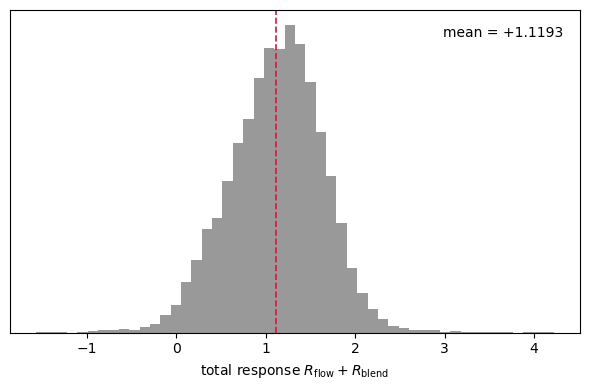

In [12]:
# Total model response per primary, weighted by detection probability.
import pandas as pd

per_primary = pd.DataFrame({
    "R_flow": pd.Series(prediction.flow, index=prediction.index),
    "R_blend": r_blend,
    "P_detect": p_detect,
})
per_primary["R_total"] = per_primary["R_flow"] + per_primary["R_blend"]
per_primary["R_total_detected"] = per_primary["R_total"] * per_primary["P_detect"]
print(
    f"mean R_total            = {per_primary['R_total'].mean():.4f}\n"
    f"mean R_total x P_detect = {per_primary['R_total_detected'].mean():.4f}"
)
# per_primary.head()

# a similar histogram of the total response
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(per_primary["R_total"], bins=50, color="0.6")
mean_total = per_primary["R_total"].mean()
ax.axvline(mean_total, color="crimson", ls="--", lw=1.2)
ax.text(0.97, 0.95, f"mean = {mean_total:+.4f}",
        transform=ax.transAxes, ha="right", va="top")
ax.set_xlabel(r"total response $R_{\mathrm{flow}} + R_{\mathrm{blend}}$")
ax.set_yticks([])
fig.tight_layout()
plt.show()

### Comparing against a simulation

Once you have a matched simulation response, the multiplicative bias is

$$m = R_{\mathrm{sim}} / R_{\mathrm{model}} - 1.$$

```python
m = prediction.multiplicative_bias(simulation_response)
print(f"m = {100 * m:+.3f}%")
```

## 5. Catalogue-level shear inference — not ready yet

The long-term goal is to skip the response-and-bias detour entirely and infer shear directly, putting the measurement flow and the neighbour emulator inside a single simulation-based likelihood.